In [62]:
import pandas as pd
import numpy as np
%pip install pandas
%pip install matplotlib
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [64]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [65]:
df = pd.read_csv("../data/study_sessions.csv")

df.head()

,sleep_hours,study_hours,break_minutes,phone_hours,stress_level,caffeine,previous_productivity,productivity
0,5.9,4.3,51,1.0,1,3,64,Medium
1,8.8,3.4,16,5.0,7,1,35,Low
2,7.7,2.2,20,2.5,8,0,97,Low
3,7.0,5.0,28,2.3,3,2,47,Medium
4,4.8,4.3,23,5.9,5,1,58,Low


In [66]:
df.shape
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sleep_hours            500 non-null    float64
 1   study_hours            500 non-null    float64
 2   break_minutes          500 non-null    int64  
 3   phone_hours            500 non-null    float64
 4   stress_level           500 non-null    int64  
 5   caffeine               500 non-null    int64  
 6   previous_productivity  500 non-null    int64  
 7   productivity           500 non-null    str    
dtypes: float64(3), int64(4), str(1)
memory usage: 31.4 KB


,sleep_hours,study_hours,break_minutes,phone_hours,stress_level,caffeine,previous_productivity
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,6.494400,3.150800,32.004000,3.213200,5.602000,1.462000,64.376000
std,1.492429,1.569965,15.458004,1.494394,2.816285,1.134518,20.031604
min,4.000000,0.500000,5.000000,0.500000,1.000000,0.000000,30.000000
25%,5.200000,1.800000,19.000000,1.900000,3.000000,0.000000,46.750000
50%,6.600000,3.100000,32.000000,3.300000,6.000000,1.000000,63.000000
75%,7.800000,4.500000,45.000000,4.300000,8.000000,2.000000,82.000000
max,9.000000,6.000000,60.000000,6.000000,10.000000,3.000000,100.000000


In [67]:
X = df.drop("productivity", axis=1)
y = df["productivity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 7)
y shape: (500,)


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 7)
Testing data: (100, 7)


In [69]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
['Low' 'Low' 'Low' 'Low' 'Low' 'Low' 'Medium' 'Medium' 'Low' 'Low']


In [70]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

phone_hours              0.224499
study_hours              0.220499
sleep_hours              0.181606
stress_level             0.145769
previous_productivity    0.123132
break_minutes            0.076050
caffeine                 0.028446
dtype: float64


In [71]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.87
Accuracy percentage: 87.0 %


In [72]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [73]:
import joblib

joblib.dump(model, "../src/study_mood_model.pkl")

print("Model saved successfully!")

Model saved successfully!


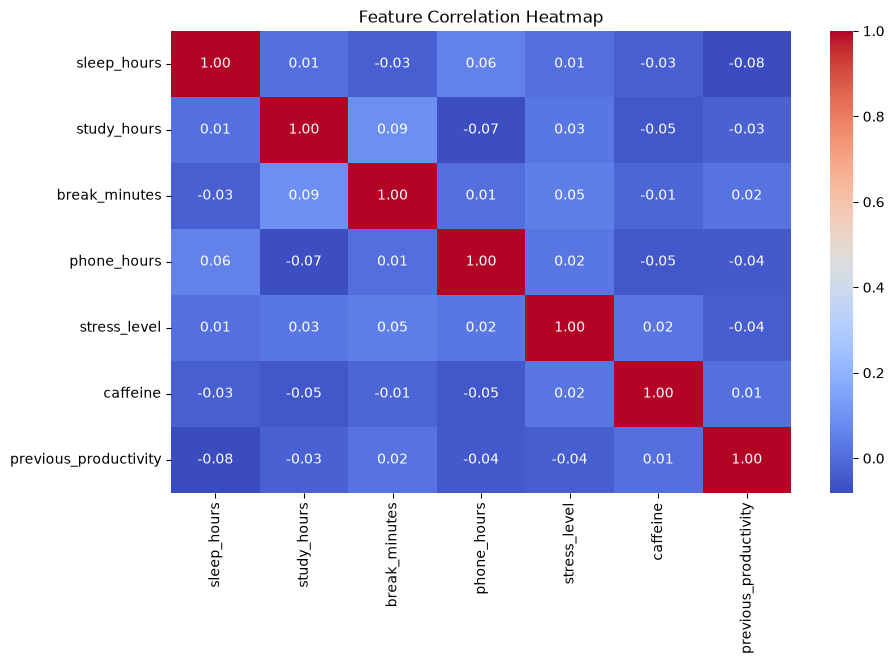

In [74]:
plt.figure(figsize=(10, 6))

correlation = df.select_dtypes(
    include="number"
).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

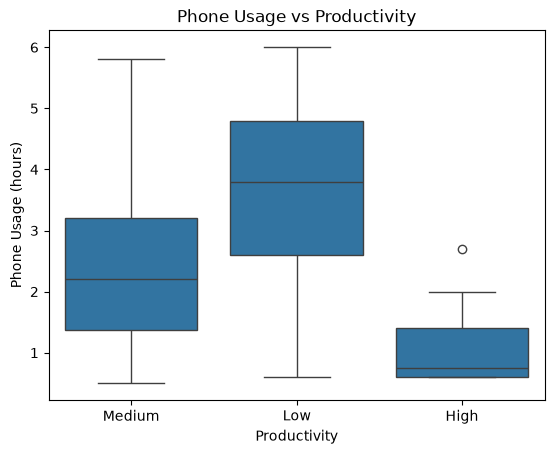

In [75]:
sns.boxplot(
    data=df,
    x="productivity",
    y="phone_hours"
)

plt.title("Phone Usage vs Productivity")
plt.xlabel("Productivity")
plt.ylabel("Phone Usage (hours)")

plt.show()

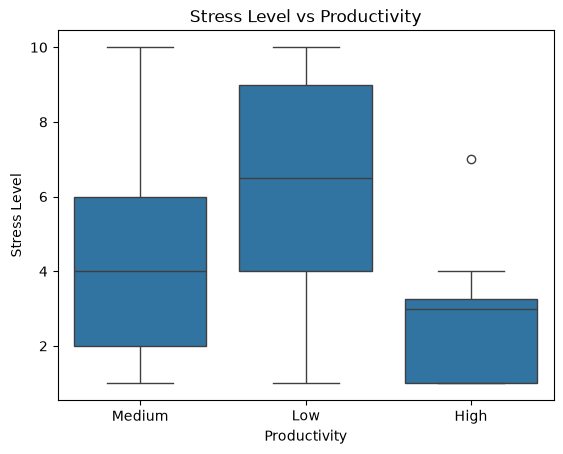

In [76]:
sns.boxplot(
    data=df,
    x="productivity",
    y="stress_level"
)

plt.title("Stress Level vs Productivity")
plt.xlabel("Productivity")
plt.ylabel("Stress Level")

plt.show()

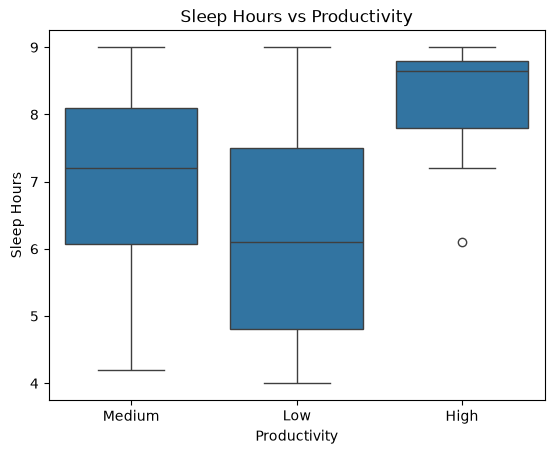

In [77]:
sns.boxplot(
    data=df,
    x="productivity",
    y="sleep_hours"
)

plt.title("Sleep Hours vs Productivity")
plt.xlabel("Productivity")
plt.ylabel("Sleep Hours")

plt.show()

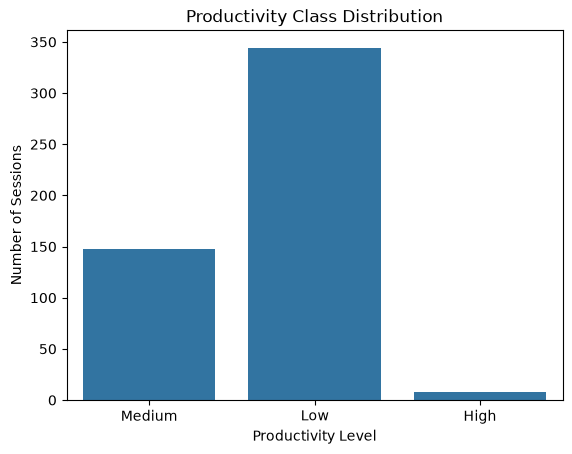

In [78]:
sns.countplot(data=df, x="productivity")

plt.title("Productivity Class Distribution")
plt.xlabel("Productivity Level")
plt.ylabel("Number of Sessions")

plt.show()

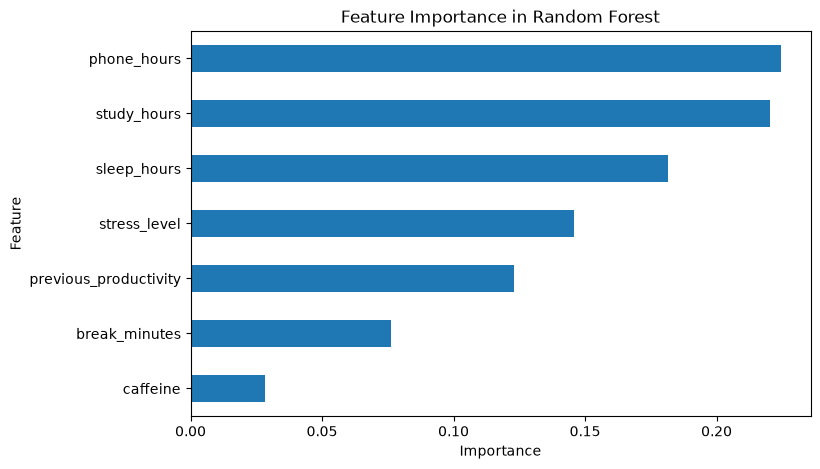

In [79]:
plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance in Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [80]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [81]:
from sklearn.tree import DecisionTreeClassifier

In [82]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree training completed!")

Decision Tree training completed!


In [83]:
dt_predictions = decision_tree.predict(X_test)

print("Decision Tree predictions generated!")
print(dt_predictions[:10])

Decision Tree predictions generated!
['Low' 'Low' 'Medium' 'Low' 'Low' 'Low' 'Medium' 'Medium' 'Low' 'Low']


In [84]:
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Accuracy (%):", dt_accuracy * 100, "%")

Decision Tree Accuracy: 0.75
Decision Tree Accuracy (%): 75.0 %


In [85]:
import joblib

rf_model = joblib.load("../src/study_mood_model.pkl")

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100, "%")

Random Forest Accuracy: 0.87
Random Forest Accuracy (%): 87.0 %


In [86]:
%pip install scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_predictions)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Logistic Regression Accuracy (%):", logistic_accuracy * 100, "%")

Note: you may need to restart the kernel to use updated packages.
Logistic Regression Accuracy: 0.95
Logistic Regression Accuracy (%): 95.0 %


In [87]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Decision Tree"],
    "Accuracy": [rf_accuracy, dt_accuracy]
})

comparison

,Model,Accuracy
0,Random Forest,0.87
1,Decision Tree,0.75


In [88]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree",
        "Logistic Regression"
    ],
    "Accuracy": [
        rf_accuracy,
        dt_accuracy,
        logistic_accuracy
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.87
1,Decision Tree,0.75
2,Logistic Regression,0.95


In [89]:
comparison.to_csv(
    "../data/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!
